# MASt3R Hands-On SPCOM Tutorial
## Instructor : Dr. Lokender Tiwari

**MASt3R** extends **DUSt3R** with a dense local-feature matching head and metric point-maps. From a pair (or several) of *unposed, uncalibrated* images it jointly recovers:

1. **Dense 2D-2D correspondences**
2. **Metric 3D point-maps** per image
3. **Camera poses & intrinsics** (via global alignment) → full **3D reconstruction**

This notebook walks through the following end-to-end tasks :
1. Single-pair inference with visualization of intermediate outputs (depth, confidence, descriptors)
2. Sparse feature matching visualization
3. Multi-view global alignment → 3D point cloud + camera trajectory (interactive Plotly viewer)
4. Export to `.ply` / `.glb`

## Step 0.  Confirm we have a GPU

In [1]:
!nvidia-smi
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Tue Jul 14 19:43:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 1. Clone MASt3R (with submodules)

MASt3R embeds DUSt3R as a git submodule, so `--recursive` is required.


In [3]:
%cd /content
!git clone --recursive https://github.com/naver/mast3r --quiet
%cd /content/mast3r
!git submodule update --init --recursive


/content
fatal: destination path 'mast3r' already exists and is not an empty directory.
/content/mast3r


## Step 2. Install dependencies

Colab already ships a recent PyTorch + CUDA build,


In [4]:
%cd /content/mast3r
!pip install -q -r requirements.txt
!pip install -q -r dust3r/requirements.txt
# Extra libs used later in this notebook for visualization / export
!pip install -q plotly trimesh
print("Dependencies installed.")


/content/mast3r
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.6 MB/s eta 0:00:00
Dependencies installed.


## Step 3. (Optional) Compile the RoPE CUDA kernels

DUSt3R/MASt3R use RoPE positional embeddings. Compiling the custom CUDA kernel speeds up inference but is optional — the model runs fine (just a bit slower)


In [5]:
# %cd /content/mast3r/dust3r/croco/models/curope/
# !python setup.py build_ext --inplace || echo "curope build failed/skipped - continuing with the slower pure-PyTorch RoPE implementation"
# %cd /content/mast3r


## Step 4. Download the pretrained MASt3R checkpoint

We use the flagship checkpoint from the paper: `MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric` (ViT-Large encoder, metric point-maps, 512px). It's ~3.5GB.


In [6]:
import os
os.makedirs('/content/mast3r/checkpoints', exist_ok=True)
%cd /content/mast3r
!wget -q --show-progress -O checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth \
    https://download.europe.naverlabs.com/ComputerVision/MASt3R/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
!ls -lh checkpoints/


/content/mast3r
checkpoints/MASt3R_ 100%[===================>]   2.57G  24.5MB/s    in 1m 50s  
total 2.6G
-rw-r--r-- 1 root root 2.6G Jul 10  2024 MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth


## Step 5. Load the model

In [7]:
import sys
sys.path.insert(0, '/content/mast3r')
sys.path.insert(0, '/content/mast3r/dust3r')

import torch
from mast3r.model import AsymmetricMASt3R

import torch
_orig_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_torch_load


device = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt_path = '/content/mast3r/checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth'

model = AsymmetricMASt3R.from_pretrained(ckpt_path).to(device)
model.eval()
print(f"MASt3R loaded on {device}")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
... loading model from /content/mast3r/checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
instantiating : AsymmetricMASt3R(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100',img_size=(512, 512), head_type='catmlp+dpt', output_mode='pts3d+desc24', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), patch_embed_cls='PatchEmbedDust3R', two_confs=True, desc_conf_mode=('exp', 0, inf), landscape_only=False)
<All keys matched successfully>
MASt3R loaded on cuda


## Step 6. Sample images

We'll start with the two-view "Chateau" pair bundled in the repo. Feel free to replace `img_paths` with your own uploaded photos (use the cell below to upload).


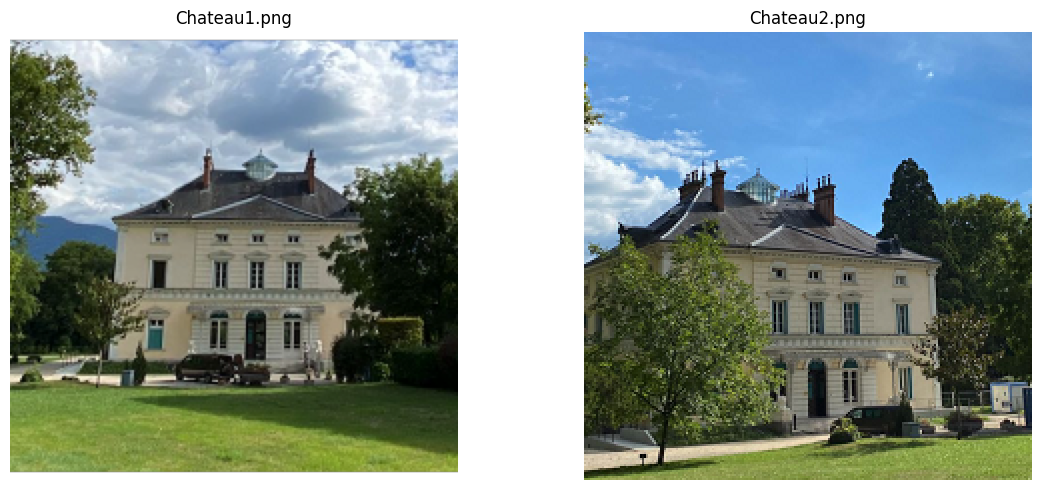

In [8]:
img_paths = [
    '/content/mast3r/dust3r/croco/assets/Chateau1.png',
    '/content/mast3r/dust3r/croco/assets/Chateau2.png',
]

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(img_paths), figsize=(6 * len(img_paths), 5))
for ax, p in zip(axes, img_paths):
    ax.imshow(Image.open(p))
    ax.axis('off')
    ax.set_title(p.split('/')[-1])
plt.tight_layout()
plt.show()


In [9]:
# Optional: uncomment to upload your own images instead
# from google.colab import files
# uploaded = files.upload()
# img_paths = list(uploaded.keys())


## Step 7. Run MASt3R inference on the pair

This produces, for each view: a metric **3D point-map** (`pts3d`), a per-pixel **confidence** map, and a dense **descriptor** map (the local-feature head that MASt3R adds on top of DUSt3R).


In [10]:
from dust3r.inference import inference
from dust3r.utils.image import load_images
from mast3r.fast_nn import fast_reciprocal_NNs

images = load_images(img_paths, size=512)
output = inference([tuple(images)], model, device, batch_size=1, verbose=False)

view1, pred1 = output['view1'], output['pred1']
view2, pred2 = output['view2'], output['pred2']

desc1, desc2 = pred1['desc'].squeeze(0).detach(), pred2['desc'].squeeze(0).detach()

print("pts3d (view1) shape :", pred1['pts3d'].shape)
print("confidence (view1)  :", pred1['conf'].shape)
print("descriptor (view1)  :", desc1.shape)


>> Loading a list of 2 images
 - adding /content/mast3r/dust3r/croco/assets/Chateau1.png with resolution 224x224 --> 512x384
 - adding /content/mast3r/dust3r/croco/assets/Chateau2.png with resolution 224x224 --> 512x384
 (Found 2 images)


/content/mast3r/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/mast3r/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


pts3d (view1) shape : torch.Size([1, 384, 512, 3])
confidence (view1)  : torch.Size([1, 384, 512])
descriptor (view1)  : torch.Size([384, 512, 24])


/content/mast3r/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


## Step 8. Visualize intermediate outputs: depth & confidence

`pts3d` is a per-pixel 3D point in the (metric) world frame — its Z-channel is effectively a depth map. `conf` tells us how much MASt3R trusts each pixel's estimate.


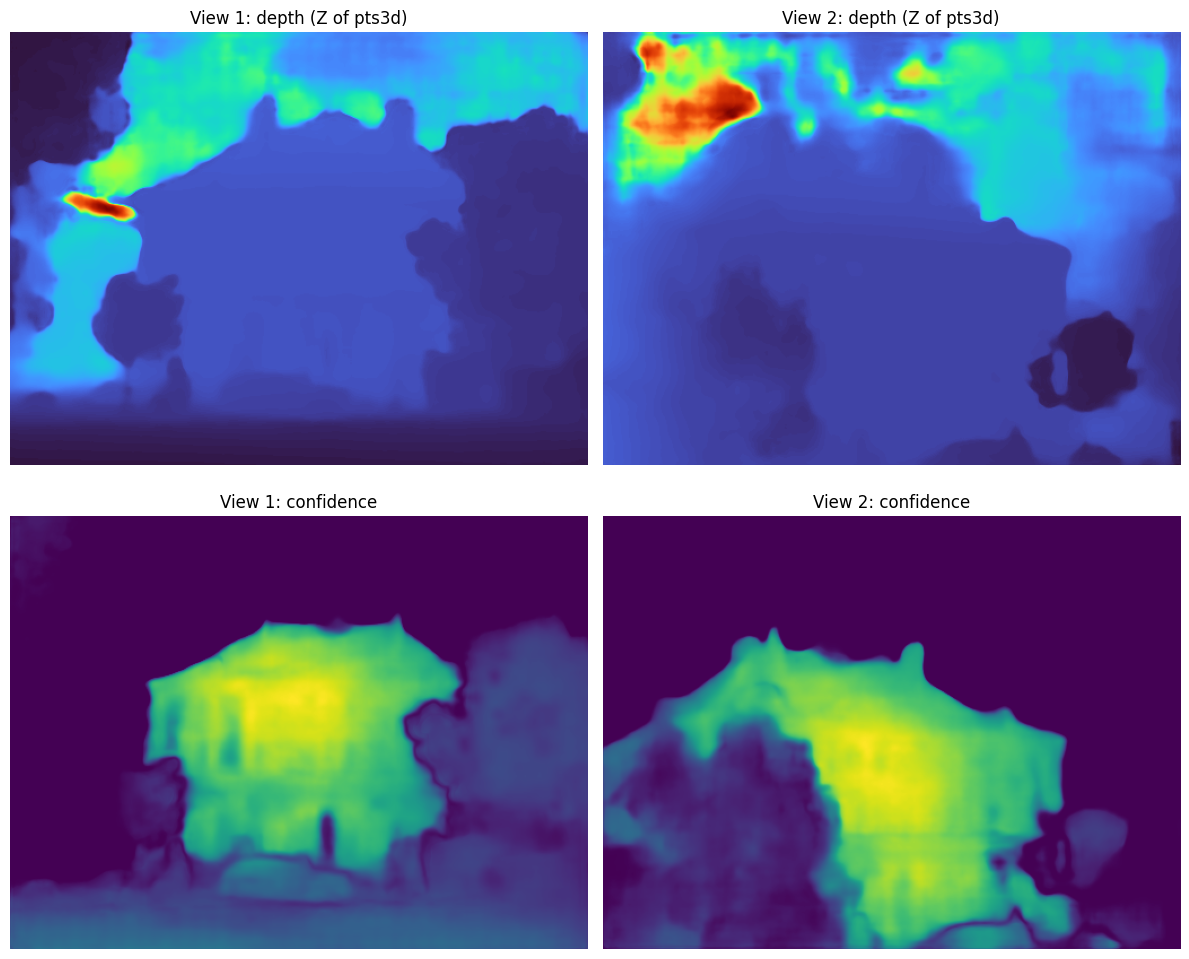

In [11]:
import numpy as np

def to_np(t):
    return t.detach().cpu().numpy()

# NOTE: pred1 stores its point-map under 'pts3d'. pred2's point-map is expressed
# in view1's coordinate frame, so it is stored under 'pts3d_in_other_view' instead.
depths = {
    'View 1': to_np(pred1['pts3d'][0, ..., 2]),
    'View 2': to_np(pred2['pts3d_in_other_view'][0, ..., 2]),
}
confs = {
    'View 1': to_np(pred1['conf'][0]),
    'View 2': to_np(pred2['conf'][0]),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, name in enumerate(['View 1', 'View 2']):
    axes[0, i].imshow(depths[name], cmap='turbo')
    axes[0, i].set_title(f'{name}: depth (Z of pts3d)')
    axes[0, i].axis('off')
    axes[1, i].imshow(confs[name], cmap='viridis')
    axes[1, i].set_title(f'{name}: confidence')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()


## Step 9. Sparse feature matching (MASt3R's local-feature head)

MASt3R's key addition over DUSt3R is a dense descriptor head trained for matching. We find mutual nearest neighbours between the two descriptor maps.


In [12]:
import numpy as np

matches_im0, matches_im1 = fast_reciprocal_NNs(
    desc1, desc2, subsample_or_initxy1=8, device=device, dist='dot', block_size=2**13
)

# Filter out matches that fall too close to image borders (standard MASt3R demo trick)
H0, W0 = view1['true_shape'][0]
H1, W1 = view2['true_shape'][0]
valid0 = (matches_im0[:, 0] >= 3) & (matches_im0[:, 0] < int(W0) - 3) & \
         (matches_im0[:, 1] >= 3) & (matches_im0[:, 1] < int(H0) - 3)
valid1 = (matches_im1[:, 0] >= 3) & (matches_im1[:, 0] < int(W1) - 3) & \
         (matches_im1[:, 1] >= 3) & (matches_im1[:, 1] < int(H1) - 3)
valid = valid0 & valid1
matches_im0, matches_im1 = matches_im0[valid], matches_im1[valid]

print(f"Found {len(matches_im0)} confident 2D-2D matches")


Found 1009 confident 2D-2D matches


### Visualize the matches

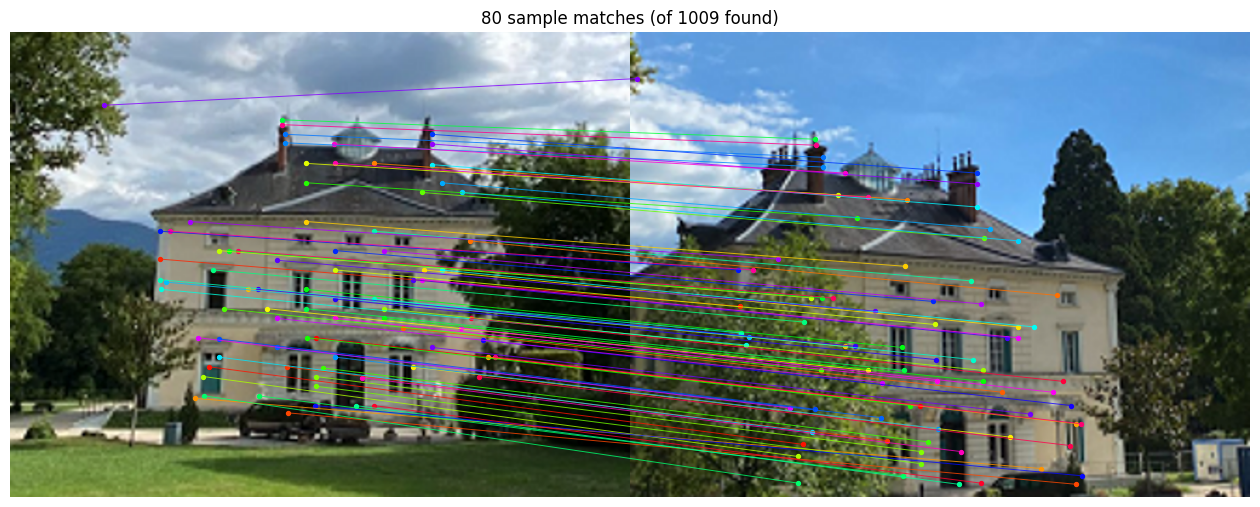

In [13]:
import numpy as np
import matplotlib.pyplot as plt

img0 = to_np(view1['img'][0]).transpose(1, 2, 0)
img1 = to_np(view2['img'][0]).transpose(1, 2, 0)
img0 = (img0 - img0.min()) / (img0.max() - img0.min())
img1 = (img1 - img1.min()) / (img1.max() - img1.min())

H, W = img0.shape[:2]
canvas = np.concatenate([img0, img1], axis=1)

n_show = min(80, len(matches_im0))
rng = np.random.default_rng(0)
idx = rng.choice(len(matches_im0), n_show, replace=False)

plt.figure(figsize=(16, 8))
plt.imshow(canvas)
cmap = plt.get_cmap('hsv')
for k, i in enumerate(idx):
    x0, y0 = matches_im0[i]
    x1, y1 = matches_im1[i]
    color = cmap(k / n_show)
    plt.plot([x0, x1 + W], [y0, y1], '-', color=color, linewidth=0.7, alpha=0.8)
    plt.scatter([x0, x1 + W], [y0, y1], color=color, s=8)
plt.axis('off')
plt.title(f'{n_show} sample matches (of {len(matches_im0)} found)')
plt.show()


## Step 10. Multi-view 3D reconstruction & pose estimation (global alignment)

This is the headline downstream task: from a set of unposed images, jointly recover **camera poses, intrinsics, and a consistent dense point cloud**. MASt3R checkpoints are compatible with DUSt3R's global aligner.

Add more image paths to `img_list` for a richer scene — even 3–6 photos of the same object/place from different angles works well.


In [15]:
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

img_list = img_paths  # reuse the 2-view Chateau pair; replace with more images if you have them

images = load_images(img_list, size=512)
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)
ga_output = inference(pairs, model, device, batch_size=1, verbose=False)

scene = global_aligner(ga_output, device=device, mode=GlobalAlignerMode.PointCloudOptimizer)
loss = scene.compute_global_alignment(init='mst', niter=300, schedule='cosine', lr=0.01)
print("Final alignment loss:", loss)


>> Loading a list of 2 images
 - adding /content/mast3r/dust3r/croco/assets/Chateau1.png with resolution 224x224 --> 512x384
 - adding /content/mast3r/dust3r/croco/assets/Chateau2.png with resolution 224x224 --> 512x384
 (Found 2 images)
 init edge (0*,1*) score=np.float64(6.45468807220459)
 init loss = 0.06124692037701607
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 300/300 [00:13<00:00, 21.83it/s, lr=1.27413e-06 loss=0.0110038]

Final alignment loss: 0.011003799736499786


### Extract the recovered poses, intrinsics and point cloud

In [16]:
imgs = scene.imgs
focals = scene.get_focals()
poses = scene.get_im_poses()
pts3d = scene.get_pts3d()
confidence_masks = scene.get_masks()

print("Recovered focal lengths:", [f.item() for f in focals])
for i, pose in enumerate(poses):
    print(f"Camera {i} pose (world-to-cam extrinsics):")
    print(to_np(pose))


Recovered focal lengths: [875.5032348632812, 1118.44091796875]
Camera 0 pose (world-to-cam extrinsics):
[[ 0.9965372  -0.0454488  -0.06962871  0.        ]
 [ 0.04544056  0.9989657  -0.00170309  0.        ]
 [ 0.06963409 -0.00146678  0.99757165  0.        ]
 [ 0.          0.          0.          1.        ]]
Camera 1 pose (world-to-cam extrinsics):
[[ 0.84213877 -0.01165084  0.53913486 -0.9916713 ]
 [ 0.03088487  0.9991675  -0.02665047 -0.02550127]
 [-0.5383756   0.03909451  0.8417976   0.152766  ]
 [ 0.          0.          0.          1.        ]]


## Step 11. Interactive 3D visualization (point cloud + camera trajectory)

Rendered inline with Plotly so it works headlessly on Colab (no X server needed).


In [17]:
import plotly.graph_objects as go
import numpy as np

all_pts, all_colors = [], []
for img, pts, mask in zip(imgs, pts3d, confidence_masks):
    p = to_np(pts)[to_np(mask)]
    c = (np.array(img).reshape(-1, 3)[to_np(mask).reshape(-1)] * 255).astype(np.uint8)
    all_pts.append(p.reshape(-1, 3))
    all_colors.append(c)

all_pts = np.concatenate(all_pts, axis=0)
all_colors = np.concatenate(all_colors, axis=0)

# Subsample for a snappy interactive plot
n_max = 60000
if len(all_pts) > n_max:
    idx = np.random.default_rng(0).choice(len(all_pts), n_max, replace=False)
    all_pts, all_colors = all_pts[idx], all_colors[idx]

color_strs = [f'rgb({r},{g},{b})' for r, g, b in all_colors]

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=all_pts[:, 0], y=all_pts[:, 1], z=all_pts[:, 2],
    mode='markers', marker=dict(size=1.5, color=color_strs), name='point cloud'
))

# Camera centers + trajectory
cam_centers = np.stack([to_np(p)[:3, 3] for p in poses])
fig.add_trace(go.Scatter3d(
    x=cam_centers[:, 0], y=cam_centers[:, 1], z=cam_centers[:, 2],
    mode='markers+lines+text',
    marker=dict(size=6, color='red'),
    line=dict(color='red', width=3),
    text=[f'cam{i}' for i in range(len(cam_centers))],
    name='camera trajectory'
))

fig.update_layout(
    scene=dict(aspectmode='data'),
    margin=dict(l=0, r=0, b=0, t=30),
    title='MASt3R reconstruction: dense point cloud + recovered camera poses'
)
fig.show()


## Step 12. Export the reconstruction (.ply)

Downloadable point cloud you can open in MeshLab / CloudCompare / Blender.


In [19]:
import trimesh

cloud = trimesh.PointCloud(vertices=all_pts, colors=all_colors)
out_path = '/content/mast3r_reconstruction.ply'
cloud.export(out_path)
print(f"Saved point cloud to {out_path}")

from google.colab import files
files.download(out_path)


Saved point cloud to /content/mast3r_reconstruction.ply


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>